## El Niño Dataset from Kaggle

In this example, we will take an original set of ocean surface temperature and air temperature measurements from around the globe and attempt to detect repeating patterns. 

We will use the popular dataset of the service **Kaggle**: [El Nino Dataset](https://www.kaggle.com/datasets/uciml/el-nino-dataset/data)
This is real-world measurement data over a long period.

### Data Preparation

Before starting the analysis, we need to transform the data into a convenient format, remove unused columns, and check the completeness and uniformity of the distribution of measurements.

In [1]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
import sys
from pathlib import Path
# shim for working with local copy
if str(Path.cwd().parent.parent.name) == 'scaleo':
    parent_dir = str(Path.cwd().parent.parent.parent)
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)

from scaleo import CWT

In [2]:
import ssl
import io
import requests
from urllib3.exceptions import InsecureRequestWarning
import seaborn as sns

# Uncomment the line bellow to suppress warnings from urllib3 if you behind enterprise firewall or have similar problems.
#requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

kaggle_elnino_url = "https://www.kaggle.com/api/v1/datasets/download/uciml/el-nino-dataset"
# kaggle_elnino_url  = "https://archive.ics.uci.edu/static/public/122/el+nino.zip"
df = pd.read_csv(kaggle_elnino_url, compression='zip')
df.columns = df.columns.str.strip()
df['Year'] = df['Year'] + 1900
for c in ['Zonal Winds', 'Meridional Winds', 'Air Temp', 'Sea Surface Temp', 'Humidity']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Time']= pd.to_datetime(df[['Year', 'Month', 'Day']])
df = df.sort_values(by=['Date', 'Latitude', 'Longitude'])
df.head(3)

,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp,Time
0,1,1980,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24,1980-03-07
1,2,1980,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97,1980-03-08
2,3,1980,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28,1980-03-09


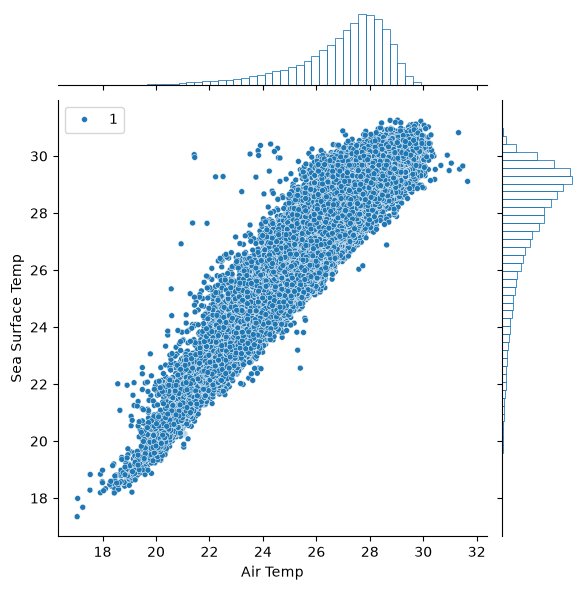

In [3]:
df.drop(columns = ['Year', 'Month', 'Day', 'Date', 'Observation'], inplace=True, errors='ignore')
sns.jointplot(x="Air Temp", y="Sea Surface Temp", data=df, size=1, marginal_kws=dict(bins=50, fill=False))

In [4]:
el_nino = df.groupby('Time')[['Humidity', 'Air Temp', 'Sea Surface Temp']].median()
el_nino

,Humidity,Air Temp,Sea Surface Temp
Time,,,
1980-03-07,NaN,26.14,26.240
1980-03-08,NaN,25.66,25.970
1980-03-09,NaN,25.69,25.280
1980-03-10,NaN,25.57,24.310
1980-03-11,NaN,25.30,23.190
...,...,...,...
1998-06-19,85.30,27.30,28.495
1998-06-20,83.80,27.41,28.590
1998-06-21,82.75,27.66,28.925


In [5]:
el_nino[el_nino['Sea Surface Temp'].isna()]

,Humidity,Air Temp,Sea Surface Temp
Time,,,
1980-03-22,NaN,26.24,NaN
1980-03-23,NaN,26.05,NaN
1980-03-24,NaN,25.67,NaN
1980-03-25,NaN,25.39,NaN
1980-03-26,NaN,25.17,NaN
...,...,...,...
1981-06-30,NaN,23.78,NaN
1981-07-01,NaN,23.66,NaN
1981-07-02,NaN,23.42,NaN


### Data Cleanup

Let's check timeline continuity and fill in the small gaps with the value ```np.nan```.

This dataset contains a <mark>large period of missing data</mark>. Let's first find it and slice from the first "good" measurement after that period onward.

In [6]:
def time_gaps(df):
    # Generate the ideal range with no gaps
    ideal_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    # Extract the dates that exist in the ideal range but are missing in df
    missing_dates = ideal_range.difference(df.index)
    return missing_dates
def larger_gap(df):
    df['time'] = pd.to_datetime(df.index)
    df = df.sort_values('time').reset_index(drop=True)
    gaps = gaps = df['time'].diff()
    largest_gap_idx = gaps.idxmax()
    start_time = df.loc[largest_gap_idx - 1, 'time']
    end_time = df.loc[largest_gap_idx, 'time']
    gap_duration = gaps.iloc[largest_gap_idx]
    return (start_time, end_time, gap_duration)


(l_start_time, l_end_time, l_gap_duration) = larger_gap(el_nino)
print("\nLarger measurement Gap starts at:", l_start_time)
print("Larger Gap ends at:", l_end_time)
print("Duration:", l_gap_duration)

print("-"*20, "\nMissing dates that will be created and their values filled with the value 'NaN':\n")
display(time_gaps(el_nino))
# make continuous time index by filling gaps
full_range = pd.date_range(start=l_end_time if l_end_time else el_nino.index.min(), end=el_nino.index.max(), freq='D')
nino = el_nino.reindex(full_range)
# nino = el_nino.fillna(0)


Larger measurement Gap starts at: 1983-04-25 00:00:00
Larger Gap ends at: 1983-10-21 00:00:00
Duration: 179 days 00:00:00
-------------------- 
Missing dates that will be created and their values filled with the value 'NaN':



DatetimeIndex(['1980-03-30', '1980-03-31', '1980-04-01', '1980-04-02',
               '1980-04-03', '1980-04-04', '1980-04-05', '1980-04-06',
               '1980-04-07', '1980-04-08',
               ...
               '1983-10-11', '1983-10-12', '1983-10-13', '1983-10-14',
               '1983-10-15', '1983-10-16', '1983-10-17', '1983-10-18',
               '1983-10-19', '1983-10-20'],
              dtype='datetime64[us]', length=312, freq=None)

### Data Analisys

Now our dataset is ready to do come CWT...

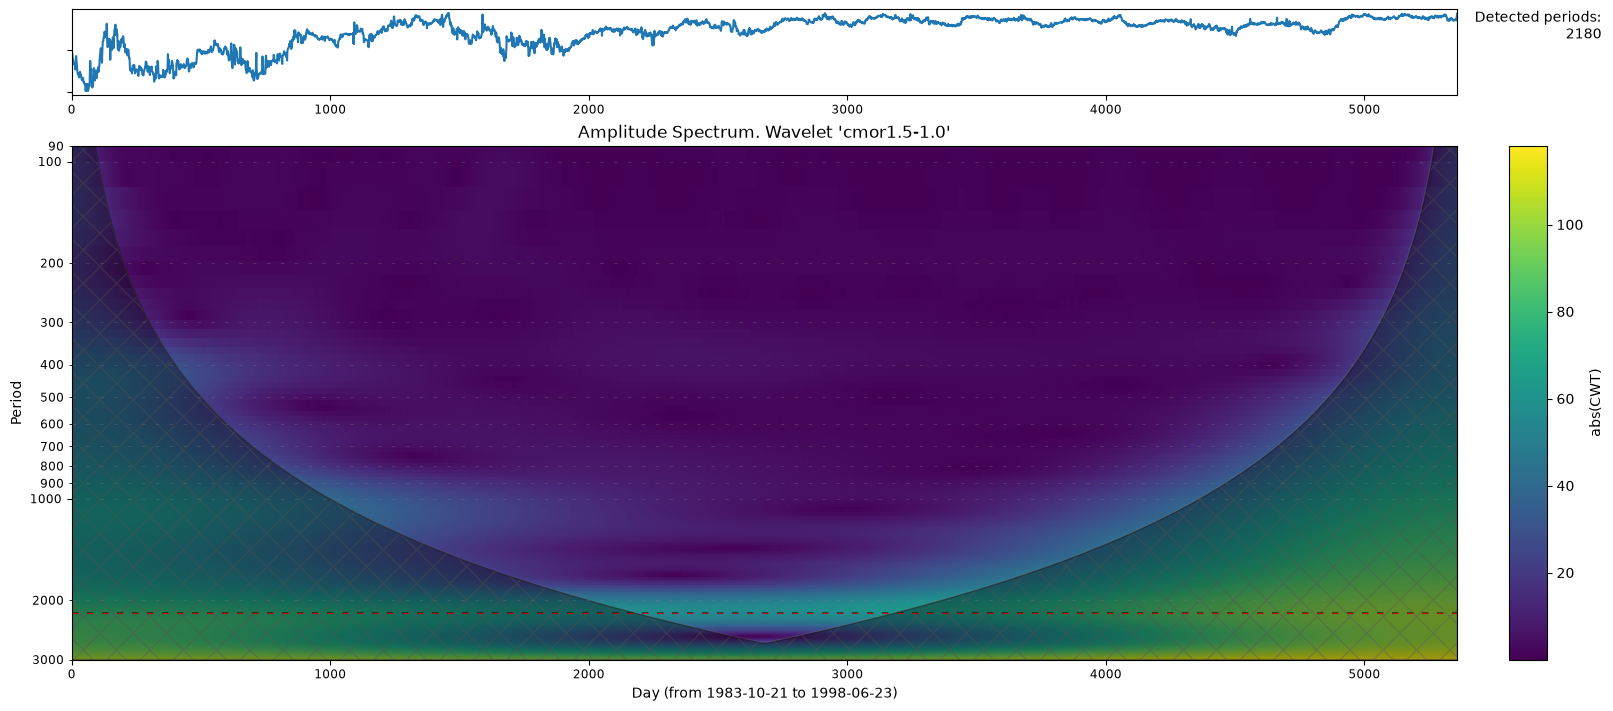

---------- 
Detected dominant periods: [2179.73] days or approx. 6.0 years


In [10]:
signal = nino['Sea Surface Temp'].to_numpy().copy()
# Days since unix epoch 1970
time = pd.to_datetime(nino.index).astype('int64')// 86400000000
time = time - time.min()
xlabel = r"Day (from " + l_end_time.strftime('%Y-%m-%d') + r" to " + pd.to_datetime(nino.index[-1]).strftime('%Y-%m-%d') + r")"

cwt = CWT(signal, 1, time, 'cmor1.5-1.0', xlabel=xlabel)
_ = cwt.cwt(periods=np.linspace(90,3000,150))
cwt.complex_plot(figsize=(16,7), cmap='viridis', spectrum='amp', coi_alpha=0.35, logscale=True, detect_peaks=True)
dominant_periods = [float(round(x,2)) for x in cwt.detect_power_peaks() if x>=2]
print("-"*10, f"\nDetected dominant periods: {dominant_periods} days or approx. {', '.join([str(round(x/364,1)) for x in dominant_periods])} years")

---

As we can see, in fully automatic mode, a clear repetition of the temperature fluctuation phenomenon is detected on average once every 6 years. This does not contradict the basic theory of the El Niño phenomenon [El Niño–Southern Oscillation](https://en.wikipedia.org/wiki/El_Ni%C3%B1o%E2%80%93Southern_Oscillation)

The peak found has a wide stripe on the scalogram. We resize the mother wavelet by increasing the frequency resolution at the expense of decreasing the temporal resolution. Also we leave only the portion of possible periods of interest on the scalogram, from ~1.5 year to 8 years.

> **Note:** Several more harmonics components with shorter periods but significanly lower signal power can be seen. This should be take into account in further investigations or use more sophisticated function for auto-detecting such components.

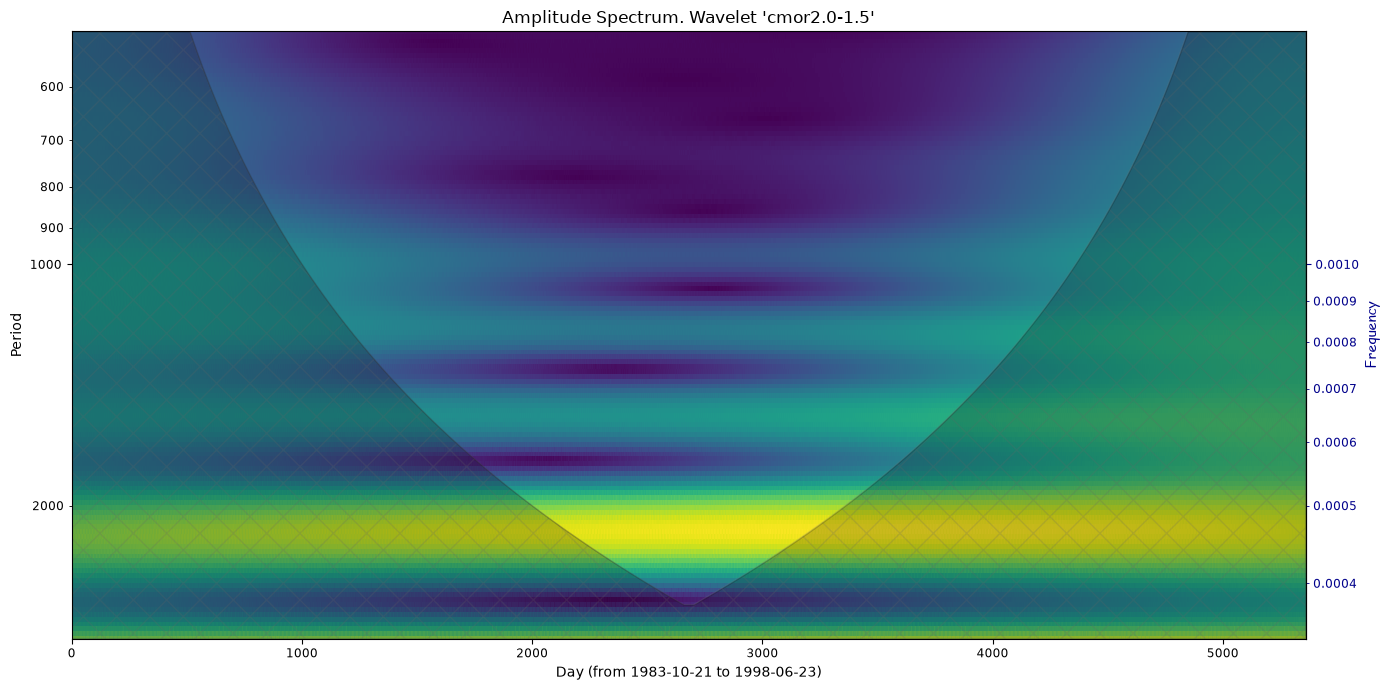

---------- 
Detected dominant periods: [986.59, 1216.33, 1542.02, 2155.53] days or approx. 2.7, 3.3, 4.2, 5.9 years


In [12]:
cwt = CWT(signal, 1, time, 'cmor2.0-1.5', xlabel=xlabel)
# cwt.cwt(periods=np.linspace(500,3000,150))
periods = np.logspace(9,12, num=150, base=2.)
periods = periods[:np.where(periods < 3000)[0].max()]
cwt.cwt(periods=periods)
cwt.scalogram(figsize=(14,7), cmap='viridis', spectrum='amp', twinticks='freq', coi_alpha=0.20, logscale=True, ygrid=False)
dominant_periods = [float(round(x,2)) for x in cwt.detect_power_peaks() if x>=2]
print("-"*10, f"\nDetected dominant periods: {dominant_periods} days or approx. {', '.join([str(round(x/364,1)) for x in dominant_periods])} years")

As you can see, we were able to isolate the frequency component more accurately at the expense of loss of precision in temporal resolution. In other words, it is now less obvious in which date range the phenomenon was observed for each of the “_highlighted_” periods.